In [36]:
# khoi0_install_wfdb_fix

import sys
import subprocess
import importlib.util

def install_package(package_name, import_name=None):
    if import_name is None:
        import_name = package_name

    if importlib.util.find_spec(import_name) is not None:
        print(f"{package_name} đã được cài.")
        return True

    print(f"Đang cài {package_name}...")

    cmd = [
        sys.executable,
        "-m",
        "pip",
        "install",
        package_name,
        "--no-cache-dir"
    ]

    result = subprocess.run(
        cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True
    )

    print(result.stdout)

    if result.returncode != 0:
        print("Cài đặt thất bại.")
        print("Nếu đang chạy trên Kaggle, hãy bật Internet = On trong phần Settings.")
        return False

    return True

ok = install_package("wfdb")

if ok:
    import wfdb
    print("WFDB version:", wfdb.__version__)

wfdb đã được cài.
WFDB version: 4.3.1


In [37]:
# khoi1_import_libraries

import os
import random
import numpy as np
import pandas as pd
import wfdb
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import layers, models, regularizers

In [38]:
#khoi2
LABELS = ["N", "L", "R", "V", "A"]

LABEL_TO_ID = {
    "N": 0,
    "L": 1,
    "R": 2,
    "V": 3,
    "A": 4
}

ID_TO_LABEL = {
    0: "N",
    1: "L",
    2: "R",
    3: "V",
    4: "A"
}

SEGMENT_LEN = 320
NUM_CLASSES = 5

# Chọn cấu hình:
# "fpga_safe": nhẹ hơn, dễ đưa lên PYNQ-Z2 hơn
# "accuracy": nhiều filter hơn, công bằng hơn khi so với CNN 169k params
MODEL_VARIANT = "accuracy"

BATCH_SIZE = 128
EPOCHS = 50

EXPORT_DIR = "/kaggle/working/fpga_export_optimized_inception"
os.makedirs(EXPORT_DIR, exist_ok=True)

print("Labels:", LABELS)
print("SEGMENT_LEN:", SEGMENT_LEN)
print("MODEL_VARIANT:", MODEL_VARIANT)
print("BATCH_SIZE:", BATCH_SIZE)
print("EPOCHS:", EPOCHS)
print("EXPORT_DIR:", EXPORT_DIR)

Labels: ['N', 'L', 'R', 'V', 'A']
SEGMENT_LEN: 320
MODEL_VARIANT: accuracy
BATCH_SIZE: 128
EPOCHS: 50
EXPORT_DIR: /kaggle/working/fpga_export_optimized_inception


In [39]:
import os
import glob

print("=== /kaggle/input ===")
print(os.listdir("/kaggle/input"))

print("\n=== Kiểm tra đường dẫn bạn đang dùng ===")

DATA_ROOT = "/kaggle/input/datasets/hongphuongtra/rtos-data1"

print("DATA_ROOT =", DATA_ROOT)
print("Exists =", os.path.exists(DATA_ROOT))

print("\n=== Tìm tất cả CSV trong /kaggle/input ===")

csv_files = glob.glob(
    "/kaggle/input/**/*.csv",
    recursive=True
)

for path in csv_files:
    print(path)

print("\nTổng CSV:", len(csv_files))

=== /kaggle/input ===
['datasets']

=== Kiểm tra đường dẫn bạn đang dùng ===
DATA_ROOT = /kaggle/input/datasets/hongphuongtra/rtos-data1
Exists = True

=== Tìm tất cả CSV trong /kaggle/input ===
/kaggle/input/datasets/hongphuongtra/rtos-data1/dataset/val.csv
/kaggle/input/datasets/hongphuongtra/rtos-data1/dataset/train.csv
/kaggle/input/datasets/hongphuongtra/rtos-data1/dataset/test.csv

Tổng CSV: 3


In [40]:
# khoi3_find_csv

import os

DATA_ROOT = "/kaggle/input/datasets/hongphuongtra/rtos-data1"

csv_dirs = []

for root, dirs, files in os.walk(DATA_ROOT):

    files_set = set(files)

    if {
        "train.csv",
        "val.csv",
        "test.csv"
    }.issubset(files_set):

        csv_dirs.append(root)


print(
    "Các thư mục có train.csv, "
    "val.csv, test.csv:"
)

for d in csv_dirs:
    print(d)


if len(csv_dirs) == 0:

    print(
        "\nKhông tìm thấy đủ 3 file."
    )

    print(
        "\nCác file CSV hiện có:"
    )

    for root, dirs, files in os.walk(DATA_ROOT):

        for file in files:

            if file.lower().endswith(".csv"):

                print(
                    os.path.join(
                        root,
                        file
                    )
                )

    raise RuntimeError(
        "Không tìm thấy train.csv, "
        "val.csv, test.csv trong dataset"
    )


CSV_DIR = csv_dirs[0]

print(
    "\nCSV_DIR =",
    CSV_DIR
)

Các thư mục có train.csv, val.csv, test.csv:
/kaggle/input/datasets/hongphuongtra/rtos-data1/dataset

CSV_DIR = /kaggle/input/datasets/hongphuongtra/rtos-data1/dataset


In [41]:
#khoi4
record_dirs = []

for root, dirs, files in os.walk("/kaggle/input"):
    has_dat = any(f.endswith(".dat") for f in files)
    has_hea = any(f.endswith(".hea") for f in files)

    if has_dat and has_hea:
        record_dirs.append(root)

print("Các thư mục có MIT-BIH .dat/.hea:")

for d in record_dirs[:20]:
    print(d)

if len(record_dirs) == 0:
    raise RuntimeError("Không tìm thấy thư mục chứa .dat và .hea")

DATASET_DIR = record_dirs[0]

print("DATASET_DIR =", DATASET_DIR)

Các thư mục có MIT-BIH .dat/.hea:
/kaggle/input/datasets/hongphuongtra/rtos-data1/dataset
/kaggle/input/datasets/hongphuongtra/rtos-data1/dataset/x_mitdb
DATASET_DIR = /kaggle/input/datasets/hongphuongtra/rtos-data1/dataset


In [42]:
#khoi5
train_df = pd.read_csv(os.path.join(CSV_DIR, "train.csv"))
val_df = pd.read_csv(os.path.join(CSV_DIR, "val.csv"))
test_df = pd.read_csv(os.path.join(CSV_DIR, "test.csv"))

print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)

print("\nTrain label distribution:")
print(train_df["labels"].value_counts())

print("\nVal label distribution:")
print(val_df["labels"].value_counts())

print("\nTest label distribution:")
print(test_df["labels"].value_counts())

display(train_df.head())

Train: (70043, 5)
Val: (15010, 5)
Test: (15009, 5)

Train label distribution:
labels
N    52530
L     5648
R     5079
V     4943
A     1843
Name: count, dtype: int64

Val label distribution:
labels
N    11204
L     1224
V     1140
R     1078
A      364
Name: count, dtype: int64

Test label distribution:
labels
N    11318
L     1203
R     1102
V     1047
A      339
Name: count, dtype: int64


,record_path,channel,start,end,labels
0,F:/Ky2nam3/do_an_1/code/mit_bih/dataset\106,MLII,520433,520752,N
1,F:/Ky2nam3/do_an_1/code/mit_bih/dataset\115,MLII,471465,471784,N
2,F:/Ky2nam3/do_an_1/code/mit_bih/dataset\215,MLII,95664,95983,N
3,F:/Ky2nam3/do_an_1/code/mit_bih/dataset\123,MLII,154633,154952,N
4,F:/Ky2nam3/do_an_1/code/mit_bih/dataset\202,MLII,469827,470146,N


In [43]:
#khoi6
def get_record_id(record_path):
    s = str(record_path).replace("\\", "/")
    base = os.path.basename(s)
    record_id = os.path.splitext(base)[0]
    return record_id


def resolve_record_base(record_path, dataset_dir):
    record_id = get_record_id(record_path)
    candidate = os.path.join(dataset_dir, record_id)

    if os.path.exists(candidate + ".hea") and os.path.exists(candidate + ".dat"):
        return candidate

    raise FileNotFoundError(
        f"Không tìm thấy record {record_id}. Cần có {candidate}.hea và {candidate}.dat"
    )


record_cache = {}

def load_record(record_path, dataset_dir):
    base = resolve_record_base(record_path, dataset_dir)

    if base not in record_cache:
        signal, fields = wfdb.rdsamp(base)
        sig_names = fields.get("sig_name", [])
        record_cache[base] = (signal.astype(np.float32), sig_names)

    return record_cache[base]

In [44]:
#khoi7
def fix_length(x, segment_len=320):
    x = np.asarray(x, dtype=np.float32).reshape(-1)

    if len(x) == segment_len:
        return x

    if len(x) > segment_len:
        center = len(x) // 2
        half = segment_len // 2
        start = max(0, center - half)
        return x[start:start + segment_len]

    pad_left = (segment_len - len(x)) // 2
    pad_right = segment_len - len(x) - pad_left

    return np.pad(x, (pad_left, pad_right), mode="constant")


def normalize_segment(x):
    x = np.asarray(x, dtype=np.float32).reshape(-1)

    mean = np.mean(x)
    std = np.std(x)

    if std < 1e-6:
        std = 1.0

    x = (x - mean) / std

    return x.astype(np.float32)


def preprocess_segment(x, segment_len=320):
    x = fix_length(x, segment_len)
    x = normalize_segment(x)
    return x.astype(np.float32)

In [45]:
#khoi8
def build_xy(csv_path, dataset_dir, segment_len=320):
    df = pd.read_csv(csv_path)
    df = df[df["labels"].isin(LABELS)].reset_index(drop=True)

    X = []
    y = []
    meta = []
    skipped = 0

    for i, row in df.iterrows():
        try:
            signal, sig_names = load_record(row["record_path"], dataset_dir)

            channel_name = str(row.get("channel", "MLII"))

            if channel_name in sig_names:
                ch = sig_names.index(channel_name)
            else:
                ch = 0

            start = int(row["start"])
            end = int(row["end"])

            segment = signal[start:end + 1, ch]
            segment = preprocess_segment(segment, segment_len)

            X.append(segment)
            y.append(LABEL_TO_ID[row["labels"]])

            meta.append({
                "record_path": row["record_path"],
                "record_id": get_record_id(row["record_path"]),
                "channel": channel_name,
                "start": start,
                "end": end,
                "label": row["labels"]
            })

        except Exception as e:
            skipped += 1

            if skipped <= 5:
                warnings.warn(f"Bỏ qua dòng {i}: {e}")

    if len(X) == 0:
        raise RuntimeError("Không tạo được dữ liệu. Kiểm tra lại CSV_DIR và DATASET_DIR.")

    X = np.stack(X).astype(np.float32)
    y = np.array(y).astype(np.int64)
    meta_df = pd.DataFrame(meta)

    print(os.path.basename(csv_path), "X =", X.shape, "y =", y.shape, "skipped =", skipped)

    return X, y, meta_df

In [46]:
#khoi9
X_train, y_train, train_meta = build_xy(
    os.path.join(CSV_DIR, "train.csv"),
    DATASET_DIR,
    SEGMENT_LEN
)

X_val, y_val, val_meta = build_xy(
    os.path.join(CSV_DIR, "val.csv"),
    DATASET_DIR,
    SEGMENT_LEN
)

X_test, y_test, test_meta = build_xy(
    os.path.join(CSV_DIR, "test.csv"),
    DATASET_DIR,
    SEGMENT_LEN
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

train.csv X = (70043, 320) y = (70043,) skipped = 0
val.csv X = (15010, 320) y = (15010,) skipped = 0
test.csv X = (15009, 320) y = (15009,) skipped = 0
X_train: (70043, 320)
X_val: (15010, 320)
X_test: (15009, 320)


In [47]:
#khoi10
import numpy as np

def add_gaussian_noise(x, noise_std=0.03):
    noise = np.random.normal(0, noise_std, size=x.shape).astype(np.float32)
    return x + noise


def amplitude_scaling(x, scale_range=(0.85, 1.15)):
    scale = np.random.uniform(scale_range[0], scale_range[1])
    return x * scale


def time_shift(x, max_shift=16):
    shift = np.random.randint(-max_shift, max_shift + 1)

    if shift == 0:
        return x.copy()

    y = np.zeros_like(x)

    if shift > 0:
        y[shift:] = x[:-shift]
    else:
        y[:shift] = x[-shift:]

    return y


def baseline_wander(x, max_amp=0.08, max_freq=2.0):
    n = len(x)
    t = np.linspace(0, 1, n)

    amp = np.random.uniform(0.0, max_amp)
    freq = np.random.uniform(0.2, max_freq)
    phase = np.random.uniform(0, 2 * np.pi)

    baseline = amp * np.sin(2 * np.pi * freq * t + phase)

    return x + baseline.astype(np.float32)


def time_stretch_1d(x, stretch_range=(0.92, 1.08)):
    n = len(x)
    stretch = np.random.uniform(stretch_range[0], stretch_range[1])

    old_idx = np.arange(n)
    new_len = max(8, int(n * stretch))
    new_idx = np.linspace(0, n - 1, new_len)

    y = np.interp(new_idx, old_idx, x)

    if new_len > n:
        start = (new_len - n) // 2
        y = y[start:start + n]
    else:
        pad_left = (n - new_len) // 2
        pad_right = n - new_len - pad_left
        y = np.pad(y, (pad_left, pad_right), mode="constant")

    return y.astype(np.float32)


def normalize_after_aug(x):
    x = x.astype(np.float32)
    mean = np.mean(x)
    std = np.std(x)

    if std < 1e-6:
        std = 1.0

    return ((x - mean) / std).astype(np.float32)


def augment_ecg_beat(x):
    y = x.copy().astype(np.float32)

    if np.random.rand() < 0.70:
        y = add_gaussian_noise(y, noise_std=np.random.uniform(0.01, 0.04))

    if np.random.rand() < 0.70:
        y = amplitude_scaling(y, scale_range=(0.85, 1.15))

    if np.random.rand() < 0.60:
        y = time_shift(y, max_shift=16)

    if np.random.rand() < 0.50:
        y = baseline_wander(y, max_amp=0.06, max_freq=1.5)

    if np.random.rand() < 0.35:
        y = time_stretch_1d(y, stretch_range=(0.94, 1.06))

    y = normalize_after_aug(y)

    return y.astype(np.float32)

In [48]:
#khoi11
def augment_train_by_class(X, y, target_per_class=None, max_aug_per_sample=5):
    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.int64)

    X_aug = [X]
    y_aug = [y]

    unique_labels, counts = np.unique(y, return_counts=True)
    count_dict = dict(zip(unique_labels, counts))

    print("Số mẫu ban đầu:")
    for cls in unique_labels:
        print(ID_TO_LABEL[int(cls)], count_dict[int(cls)])

    if target_per_class is None:
        max_count = max(counts)

        target_per_class = {}
        for cls in unique_labels:
            if ID_TO_LABEL[int(cls)] == "A":
                target_per_class[int(cls)] = min(max_count, count_dict[int(cls)] * 5)
            elif ID_TO_LABEL[int(cls)] == "V":
                target_per_class[int(cls)] = min(max_count, count_dict[int(cls)] * 2)
            else:
                target_per_class[int(cls)] = count_dict[int(cls)]

    for cls in unique_labels:
        cls = int(cls)

        current_count = count_dict[cls]
        target_count = int(target_per_class.get(cls, current_count))

        need = max(0, target_count - current_count)

        if need == 0:
            continue

        cls_indices = np.where(y == cls)[0]

        new_X = []
        new_y = []

        for i in range(need):
            idx = np.random.choice(cls_indices)
            aug = augment_ecg_beat(X[idx])

            new_X.append(aug)
            new_y.append(cls)

        X_aug.append(np.stack(new_X).astype(np.float32))
        y_aug.append(np.array(new_y).astype(np.int64))

        print(
            "Augment lớp",
            ID_TO_LABEL[cls],
            "| hiện có:",
            current_count,
            "| sinh thêm:",
            need,
            "| sau augment:",
            current_count + need
        )

    X_out = np.concatenate(X_aug, axis=0)
    y_out = np.concatenate(y_aug, axis=0)

    perm = np.random.permutation(len(X_out))
    X_out = X_out[perm]
    y_out = y_out[perm]

    return X_out.astype(np.float32), y_out.astype(np.int64)


X_train_aug, y_train_aug = augment_train_by_class(
    X_train,
    y_train,
    target_per_class=None
)

print("X_train_aug:", X_train_aug.shape)
print("y_train_aug:", y_train_aug.shape)

print("\nSố mẫu sau augmentation:")
for i in range(NUM_CLASSES):
    print(ID_TO_LABEL[i], int(np.sum(y_train_aug == i)))

Số mẫu ban đầu:
N 52530
L 5648
R 5079
V 4943
A 1843
Augment lớp V | hiện có: 4943 | sinh thêm: 4943 | sau augment: 9886
Augment lớp A | hiện có: 1843 | sinh thêm: 7372 | sau augment: 9215
X_train_aug: (82358, 320)
y_train_aug: (82358,)

Số mẫu sau augmentation:
N 52530
L 5648
R 5079
V 9886
A 9215


In [49]:
#khoi12
X_train_keras = X_train_aug[..., np.newaxis].astype(np.float32)
y_train_cat = tf.keras.utils.to_categorical(y_train_aug, num_classes=NUM_CLASSES)

X_val_keras = X_val[..., np.newaxis].astype(np.float32)
y_val_cat = tf.keras.utils.to_categorical(y_val, num_classes=NUM_CLASSES)

X_test_keras = X_test[..., np.newaxis].astype(np.float32)
y_test_cat = tf.keras.utils.to_categorical(y_test, num_classes=NUM_CLASSES)

print("X_train_keras:", X_train_keras.shape)
print("y_train_cat:", y_train_cat.shape)

print("X_val_keras:", X_val_keras.shape)
print("X_test_keras:", X_test_keras.shape)

X_train_keras: (82358, 320, 1)
y_train_cat: (82358, 5)
X_val_keras: (15010, 320, 1)
X_test_keras: (15009, 320, 1)


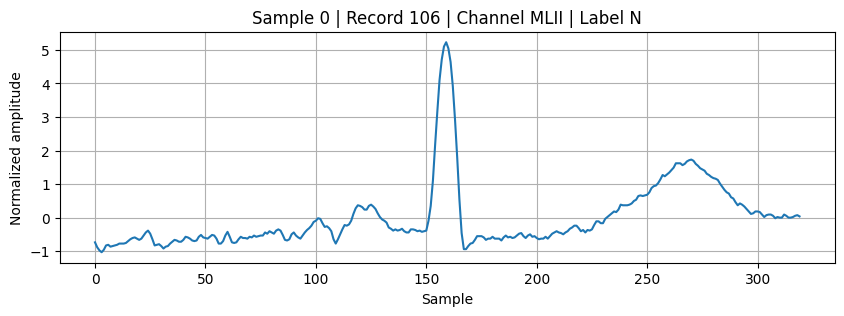

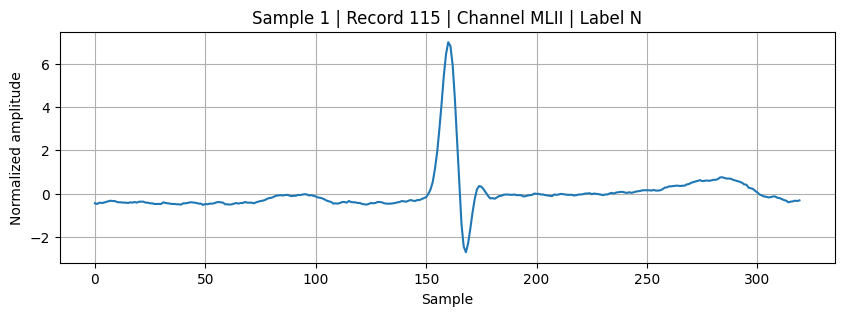

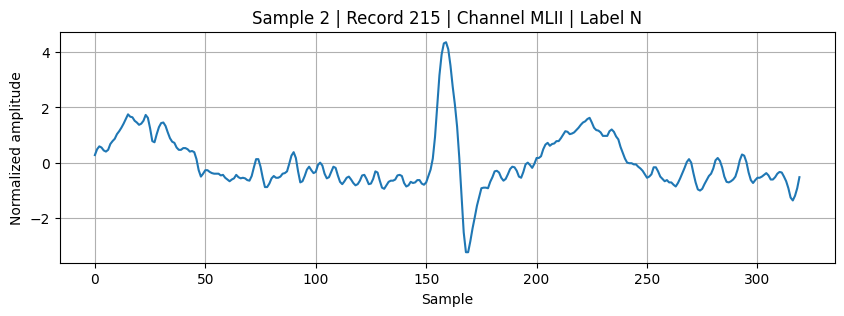

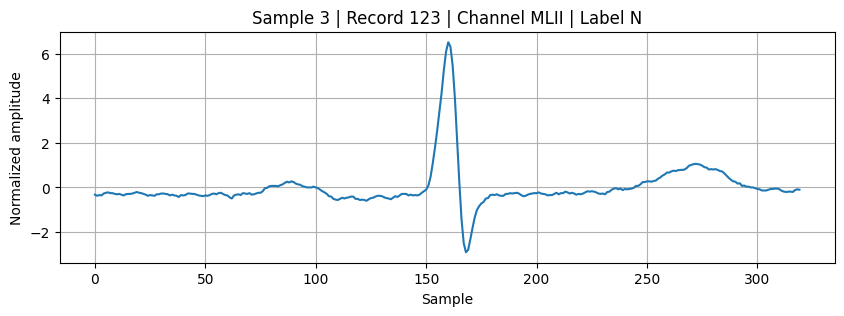

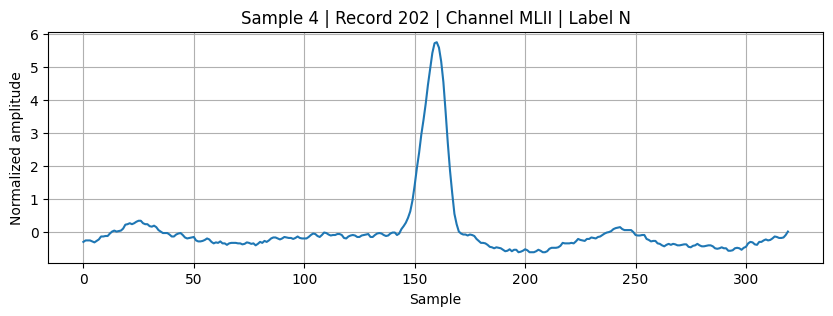

In [50]:
#khoi13
for i in range(5):
    row = train_meta.iloc[i]

    plt.figure(figsize=(10, 3))
    plt.plot(X_train[i])
    plt.title(
        f"Sample {i} | Record {row['record_id']} | "
        f"Channel {row['channel']} | Label {row['label']}"
    )
    plt.xlabel("Sample")
    plt.ylabel("Normalized amplitude")
    plt.grid(True)
    plt.show()

In [51]:
# ============================================================
# BLOCK 14 - BUILD SEPARABLE RESIDUAL INCEPTION MODEL
# ============================================================

import os
import numpy as np
import tensorflow as tf

from tensorflow.keras import (
    layers,
    regularizers,
    Model
)


LABELS_5 = [
    "N",
    "L",
    "R",
    "V",
    "A"
]

NUM_CLASSES_5 = 5

input_shape_5 = (
    X_train_keras.shape[1:]
)

L2_LAMBDA = 1e-4

DROPOUT_1 = 0.06
DROPOUT_2 = 0.08
DROPOUT_HEAD = 0.25


# ============================================================
# BASIC BN + GELU
# ============================================================

def bn_gelu(
    x,
    name
):
    x = layers.BatchNormalization(
        name=f"{name}_bn"
    )(x)

    x = layers.Activation(
        "gelu",
        name=f"{name}_gelu"
    )(x)

    return x


# ============================================================
# SEPARABLE CONVOLUTION BRANCH
# ============================================================

def sep_conv_branch(
    x,
    filters,
    kernel_size,
    dilation_rate,
    name
):
    y = layers.SeparableConv1D(
        filters=filters,
        kernel_size=kernel_size,
        padding="same",
        dilation_rate=dilation_rate,
        use_bias=False,

        depthwise_regularizer=
            regularizers.l2(
                L2_LAMBDA
            ),

        pointwise_regularizer=
            regularizers.l2(
                L2_LAMBDA
            ),

        name=f"{name}_sepconv"
    )(x)

    y = bn_gelu(
        y,
        name=name
    )

    return y


# ============================================================
# RESIDUAL INCEPTION BLOCK
# ============================================================

def sep_res_inception_block(
    x,
    filters,
    dropout_rate,
    block_name
):
    shortcut = x

    branch_filters = max(
        filters // 2,
        4
    )

    # -------------------------
    # Branch 1 - Kernel 3
    # -------------------------

    b1 = sep_conv_branch(
        x,
        filters=branch_filters,
        kernel_size=3,
        dilation_rate=1,
        name=f"{block_name}_b1_k3"
    )

    # -------------------------
    # Branch 2 - Kernel 5
    # -------------------------

    b2 = sep_conv_branch(
        x,
        filters=branch_filters,
        kernel_size=5,
        dilation_rate=1,
        name=f"{block_name}_b2_k5"
    )

    # -------------------------
    # Branch 3 - Kernel 7
    # Dilation = 2
    # -------------------------

    b3 = sep_conv_branch(
        x,
        filters=branch_filters,
        kernel_size=7,
        dilation_rate=2,
        name=f"{block_name}_b3_k7_d2"
    )

    # -------------------------
    # Branch 4 - Pool + 1x1
    # -------------------------

    b4 = layers.MaxPooling1D(
        pool_size=3,
        strides=1,
        padding="same",
        name=f"{block_name}_b4_pool"
    )(x)

    b4 = layers.Conv1D(
        branch_filters,
        kernel_size=1,
        padding="same",
        use_bias=False,

        kernel_regularizer=
            regularizers.l2(
                L2_LAMBDA
            ),

        name=f"{block_name}_b4_conv1x1"
    )(b4)

    b4 = bn_gelu(
        b4,
        name=f"{block_name}_b4"
    )

    # -------------------------
    # Merge 4 branches
    # -------------------------

    y = layers.Concatenate(
        name=f"{block_name}_concat"
    )([
        b1,
        b2,
        b3,
        b4
    ])

    # -------------------------
    # Output projection
    # -------------------------

    y = layers.Conv1D(
        filters,
        kernel_size=1,
        padding="same",
        use_bias=False,

        kernel_regularizer=
            regularizers.l2(
                L2_LAMBDA
            ),

        name=f"{block_name}_projection"
    )(y)

    y = layers.BatchNormalization(
        name=f"{block_name}_projection_bn"
    )(y)

    # -------------------------
    # Residual shortcut
    # -------------------------

    if int(
        shortcut.shape[-1]
    ) != filters:

        shortcut = layers.Conv1D(
            filters,
            kernel_size=1,
            padding="same",
            use_bias=False,

            kernel_regularizer=
                regularizers.l2(
                    L2_LAMBDA
                ),

            name=f"{block_name}_shortcut"
        )(shortcut)

        shortcut = layers.BatchNormalization(
            name=f"{block_name}_shortcut_bn"
        )(shortcut)

    # -------------------------
    # Residual Add
    # -------------------------

    y = layers.Add(
        name=f"{block_name}_add"
    )([
        shortcut,
        y
    ])

    y = layers.Activation(
        "gelu",
        name=f"{block_name}_output_gelu"
    )(y)

    y = layers.SpatialDropout1D(
        dropout_rate,
        name=f"{block_name}_output"
    )(y)

    return y


# ============================================================
# INPUT
# ============================================================

inp = layers.Input(
    shape=input_shape_5,
    name="ecg_input"
)


# ============================================================
# STEM
# ============================================================

x = layers.Conv1D(
    filters=8,
    kernel_size=7,
    padding="same",
    use_bias=False,

    kernel_regularizer=
        regularizers.l2(
            L2_LAMBDA
        ),

    name="stem_conv_k7"
)(inp)

x = bn_gelu(
    x,
    name="stem"
)


# ============================================================
# INCEPTION BLOCK 1
# Input : 320 x 8
# Output: 320 x 8
# ============================================================

x = sep_res_inception_block(
    x,
    filters=8,
    dropout_rate=DROPOUT_1,
    block_name="block1"
)


# ============================================================
# DOWNSAMPLE 1
# 320 -> 160
# ============================================================

x = layers.MaxPooling1D(
    pool_size=2,
    name="downsample1"
)(x)


# ============================================================
# INCEPTION BLOCK 2
# Input : 160 x 8
# Output: 160 x 12
# ============================================================

x = sep_res_inception_block(
    x,
    filters=12,
    dropout_rate=DROPOUT_1,
    block_name="block2"
)


# ============================================================
# DOWNSAMPLE 2
# 160 -> 80
# ============================================================

x = layers.MaxPooling1D(
    pool_size=2,
    name="downsample2"
)(x)


# ============================================================
# INCEPTION BLOCK 3
# Input : 80 x 12
# Output: 80 x 16
# ============================================================

x = sep_res_inception_block(
    x,
    filters=16,
    dropout_rate=DROPOUT_2,
    block_name="block3"
)


# ============================================================
# DOWNSAMPLE 3
# 80 -> 40
# ============================================================

x = layers.MaxPooling1D(
    pool_size=2,
    name="downsample3"
)(x)


# ============================================================
# INCEPTION BLOCK 4
# Input : 40 x 16
# Output: 40 x 20
# ============================================================

x = sep_res_inception_block(
    x,
    filters=20,
    dropout_rate=DROPOUT_2,
    block_name="block4"
)


# ============================================================
# CLASSIFIER HEAD
# ============================================================

gap = layers.GlobalAveragePooling1D(
    name="head_global_avg_pool"
)(x)

gmp = layers.GlobalMaxPooling1D(
    name="head_global_max_pool"
)(x)

x = layers.Concatenate(
    name="head_concat"
)([
    gap,
    gmp
])

x = layers.Dense(
    24,
    use_bias=False,

    kernel_regularizer=
        regularizers.l2(
            L2_LAMBDA
        ),

    name="head_dense"
)(x)

x = layers.BatchNormalization(
    name="head_bn"
)(x)

x = layers.Activation(
    "gelu",
    name="head_gelu"
)(x)

x = layers.Dropout(
    DROPOUT_HEAD,
    name="head_dropout"
)(x)


# ============================================================
# OUTPUT
# ============================================================

out = layers.Dense(
    NUM_CLASSES_5,
    activation="softmax",
    name="class_output"
)(x)


# ============================================================
# MODEL
# ============================================================

inception_model = Model(
    inp,
    out,
    name="sep_res_inception_gelu_5class"
)


# ============================================================
# COMPILE
# ============================================================

inception_model.compile(

    optimizer=
        tf.keras.optimizers.Adam(
            learning_rate=1e-3
        ),

    loss=
        tf.keras.losses
        .CategoricalCrossentropy(
            label_smoothing=0.03
        ),

    metrics=[
        "accuracy"
    ]
)


# ============================================================
# SUMMARY
# ============================================================

inception_model.summary()

print()

print(
    "New model params:",
    f"{inception_model.count_params():,}"
)

if "best_5class_model" in globals():

    try:
        print(
            "Old model params:",
            f"{best_5class_model.count_params():,}"
        )

    except:
        pass

I0000 00:00:1789909996.766575      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789909996.772515      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sep_res_inception_gelu_5class"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ ecg_input           │ (None, 320, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_k7        │ (None, 320, 8)    │         56 │ ecg_input[0][0]   │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 320, 8)    │         32 │ stem_conv_k7[0][… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_gelu           │ (None, 320, 8)    │          0 │ stem_bn[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_b4_pool      │ (None, 320, 8)    │          0 │ stem_gelu[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_b1_k3_sepco… │ (None, 320, 4)    │         56 │ stem_gelu[0][0]   │
│ (SeparableConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_b2_k5_sepco… │ (None, 320, 4)    │         72 │ stem_gelu[0][0]   │
│ (SeparableConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_b3_k7_d2_se… │ (None, 320, 4)    │         88 │ stem_gelu[0][0]   │
│ (SeparableConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_b4_conv1x1   │ (None, 320, 4)    │         32 │ block1_b4_pool[0… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_b1_k3_bn     │ (None, 320, 4)    │         16 │ block1_b1_k3_sep… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_b2_k5_bn     │ (None, 320, 4)    │         16 │ block1_b2_k5_sep… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_b3_k7_d2_bn  │ (None, 320, 4)    │         16 │ block1_b3_k7_d2_… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_b4_bn        │ (None, 320, 4)    │         16 │ block1_b4_conv1x… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_b1_k3_gelu   │ (None, 320, 4)    │          0 │ block1_b1_k3_bn[… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_b2_k5_gelu   │ (None, 320, 4)    │          0 │ block1_b2_k5_bn[… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_b3_k7_d2_ge… │ (None, 320, 4)    │          0 │ block1_b3_k7_d2_… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_b4_gelu      │ (None, 320, 4)    │          0 │ block1_b4_bn[0][

 Total params: 6,473 (25.29 KB)

 Trainable params: 5,977 (23.35 KB)

 Non-trainable params: 496 (1.94 KB)


New model params: 6,473


In [52]:
#khoi15
def count_conv_dense_params(model):
    total = 0
    details = []

    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.Conv1D):
            params = layer.count_params()
            total += params
            details.append((layer.name, "Conv1D", params))

        if isinstance(layer, tf.keras.layers.Dense):
            params = layer.count_params()
            total += params
            details.append((layer.name, "Dense", params))

    df_params = pd.DataFrame(
        details,
        columns=["layer", "type", "params"]
    )

    return total, df_params


total_keras_params = inception_model.count_params()
total_inference_params, df_params = count_conv_dense_params(inception_model)

print("Tổng tham số Keras:", total_keras_params)
print("Tham số Conv + Dense dùng cho FPGA sau khi fuse BN:", total_inference_params)

display(df_params)

if total_inference_params < 6000:
    print("Đạt mục tiêu: tham số inference < 6000.")
else:
    print("Chưa đạt mục tiêu: cần giảm channel hoặc Dense.")

Tổng tham số Keras: 6473
Tham số Conv + Dense dùng cho FPGA sau khi fuse BN: 3813


,layer,type,params
0,stem_conv_k7,Conv1D,56
1,block1_b4_conv1x1,Conv1D,32
2,block1_projection,Conv1D,128
3,block2_b4_conv1x1,Conv1D,48
4,block2_shortcut,Conv1D,96
5,block2_projection,Conv1D,288
6,block3_b4_conv1x1,Conv1D,96
7,block3_shortcut,Conv1D,192
8,block3_projection,Conv1D,512
9,block4_b4_conv1x1,Conv1D,160


Đạt mục tiêu: tham số inference < 6000.


# train

In [53]:
#khoi16_train_sep_res_inception_gelu_no_A_weight_fix

import os
import tensorflow as tf

best_inception_path = "/kaggle/working/best_optimized_mini_inception.keras"

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        best_inception_path,
        monitor="val_loss",
        save_best_only=True,
        mode="min",
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=9,
        min_delta=1e-4,
        restore_best_weights=True,
        mode="min",
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        mode="min",
        verbose=1
    )
]

history = inception_model.fit(
    X_train_keras,
    y_train_cat,
    validation_data=(
        X_val_keras,
        y_val_cat
    ),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    shuffle=True,
    verbose=1
)

best_inception_model = tf.keras.models.load_model(
    best_inception_path,
    compile=False
)

best_5class_model = best_inception_model
model_5class = best_inception_model

print()
print("Best model saved at:", best_inception_path)
print("Loaded best 5-class model:")
print("Input shape:", best_inception_model.input_shape)
print("Output shape:", best_inception_model.output_shape)
print("Params:", f"{best_inception_model.count_params():,}")
print("File tồn tại:", os.path.exists(best_inception_path))

Epoch 1/50


I0000 00:00:1789910013.954987     136 service.cc:152] XLA service 0x7e8384010ce0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1789910013.955039     136 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1789910013.955045     136 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1789910016.438463     136 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1789910042.623619     136 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


644/644 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.6405 - loss: 1.0321
Epoch 1: val_loss improved from None to 0.41451, saving model to /kaggle/working/best_optimized_mini_inception.keras

Epoch 1: finished saving model to /kaggle/working/best_optimized_mini_inception.keras
644/644 ━━━━━━━━━━━━━━━━━━━━ 108s 91ms/step - accuracy: 0.7657 - loss: 0.7844 - val_accuracy: 0.9394 - val_loss: 0.4145 - learning_rate: 0.0010
Epoch 2/50
644/644 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8831 - loss: 0.5187
Epoch 2: val_loss improved from 0.41451 to 0.28518, saving model to /kaggle/working/best_optimized_mini_inception.keras

Epoch 2: finished saving model to /kaggle/working/best_optimized_mini_inception.keras
644/644 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.8952 - loss: 0.4888 - val_accuracy: 0.9672 - val_loss: 0.2852 - learning_rate: 0.0010
Epoch 3/50
644/644 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9201 - loss: 0.4277
Epoch 3: val_loss improved from 0.28518 to 0.27445, 

In [54]:
#khoi17
best_inception_model = tf.keras.models.load_model(
    best_inception_path,
    compile=False
)

print("Đã load model tốt nhất:", best_inception_path)

Đã load model tốt nhất: /kaggle/working/best_optimized_mini_inception.keras


In [55]:
#khoi18
#khoi_evaluate_model

import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_prob = inception_model.predict(X_test_keras)
y_pred = np.argmax(y_prob, axis=1)

y_test_arr = np.asarray(y_test)

if y_test_arr.ndim > 1:
    y_test_label = np.argmax(y_test_arr, axis=1)
else:
    y_test_label = y_test_arr.astype(np.int32).ravel()

test_acc = accuracy_score(y_test_label, y_pred)

print("Test accuracy:", round(test_acc, 4))
print("Test accuracy (%):", round(test_acc * 100, 2))

print("\nClassification report:")
print(classification_report(
    y_test_label,
    y_pred,
    target_names=["N", "L", "R", "V", "A"],
    digits=4
))


470/470 ━━━━━━━━━━━━━━━━━━━━ 27s 30ms/step
Test accuracy: 0.9923
Test accuracy (%): 99.23

Classification report:
              precision    recall  f1-score   support

           N     0.9943    0.9969    0.9956     11318
           L     0.9975    0.9909    0.9942      1203
           R     0.9936    0.9909    0.9923      1102
           V     0.9818    0.9799    0.9809      1047
           A     0.9317    0.8850    0.9077       339

    accuracy                         0.9923     15009
   macro avg     0.9798    0.9687    0.9741     15009
weighted avg     0.9922    0.9923    0.9922     15009



## heatmap

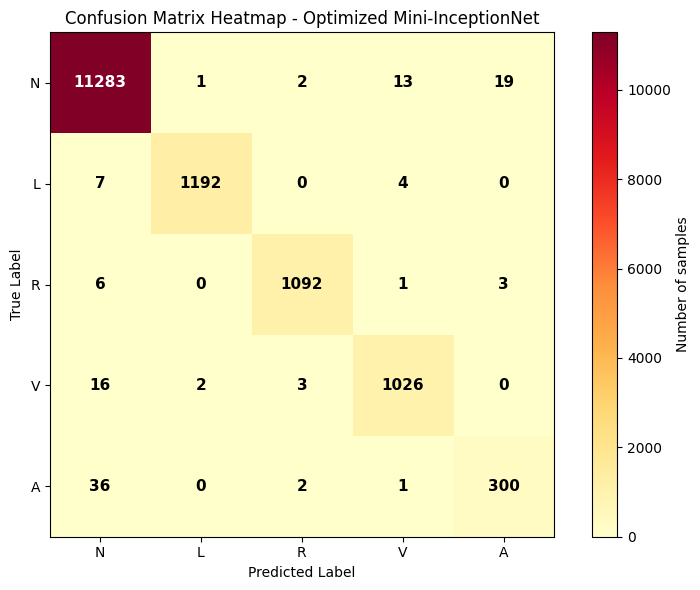

In [56]:
#khoi_19_heatmap_confusion_matrix

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

CLASS_NAMES = ["N", "L", "R", "V", "A"]

cm = confusion_matrix(y_test_label, y_pred)

plt.figure(figsize=(8, 6))

im = plt.imshow(
    cm,
    interpolation="nearest",
    cmap="YlOrRd"
)

plt.title("Confusion Matrix Heatmap - Optimized Mini-InceptionNet")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(np.arange(len(CLASS_NAMES)), CLASS_NAMES)
plt.yticks(np.arange(len(CLASS_NAMES)), CLASS_NAMES)

cbar = plt.colorbar(im)
cbar.set_label("Number of samples")

threshold = cm.max() / 2

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center",
            color="white" if cm[i, j] > threshold else "black",
            fontsize=11,
            fontweight="bold"
        )

plt.tight_layout()
plt.show()

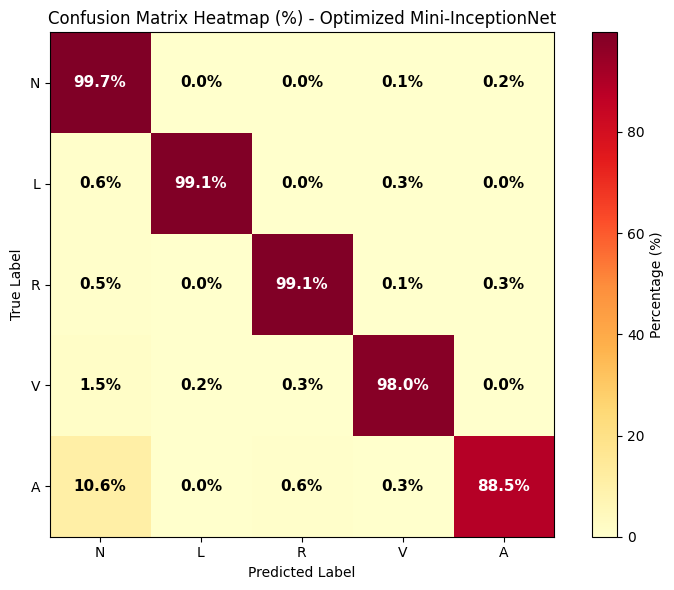

In [57]:
#khoi_heatmap_confusion_matrix

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

CLASS_NAMES = ["N", "L", "R", "V", "A"]

cm = confusion_matrix(
    y_test_label,
    y_pred,
    labels=[0, 1, 2, 3, 4]
)

cm = cm.astype(np.float32)

row_sum = cm.sum(axis=1, keepdims=True)
row_sum[row_sum == 0] = 1.0

cm_percent = cm / row_sum * 100.0

plt.figure(figsize=(8, 6))

im = plt.imshow(
    cm_percent,
    interpolation="nearest",
    cmap="YlOrRd"
)

plt.title("Confusion Matrix Heatmap (%) - Optimized Mini-InceptionNet")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(np.arange(len(CLASS_NAMES)), CLASS_NAMES)
plt.yticks(np.arange(len(CLASS_NAMES)), CLASS_NAMES)

cbar = plt.colorbar(im)
cbar.set_label("Percentage (%)")

threshold = cm_percent.max() / 2 if cm_percent.max() > 0 else 0

for i in range(cm_percent.shape[0]):
    for j in range(cm_percent.shape[1]):
        plt.text(
            j,
            i,
            f"{cm_percent[i, j]:.1f}%",
            ha="center",
            va="center",
            color="white" if cm_percent[i, j] > threshold else "black",
            fontsize=11,
            fontweight="bold"
        )

plt.tight_layout()
plt.show()

In [58]:
#khoi20
report = classification_report(
    y_test,
    y_pred,
    target_names=LABELS,
    output_dict=True,
    digits=4
)

report_df = pd.DataFrame(report).T

display(report_df)

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=[0, 1, 2, 3, 4]
)

cm_df = pd.DataFrame(
    cm,
    index=[f"True_{label}" for label in LABELS],
    columns=[f"Pred_{label}" for label in LABELS]
)

display(cm_df)

,precision,recall,f1-score,support
N,0.994272,0.996908,0.995588,11318.000000
L,0.997490,0.990856,0.994162,1203.000000
R,0.993631,0.990926,0.992276,1102.000000
V,0.981818,0.979943,0.980880,1047.000000
A,0.931677,0.884956,0.907716,339.000000
accuracy,0.992271,0.992271,0.992271,0.992271
macro avg,0.979777,0.968718,0.974124,15009.000000
weighted avg,0.992200,0.992271,0.992220,15009.000000


,Pred_N,Pred_L,Pred_R,Pred_V,Pred_A
True_N,11283,1,2,13,19
True_L,7,1192,0,4,0
True_R,6,0,1092,1,3
True_V,16,2,3,1026,0
True_A,36,0,2,1,300


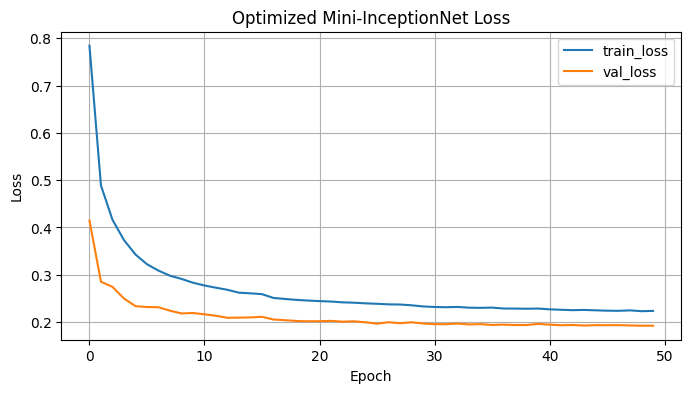

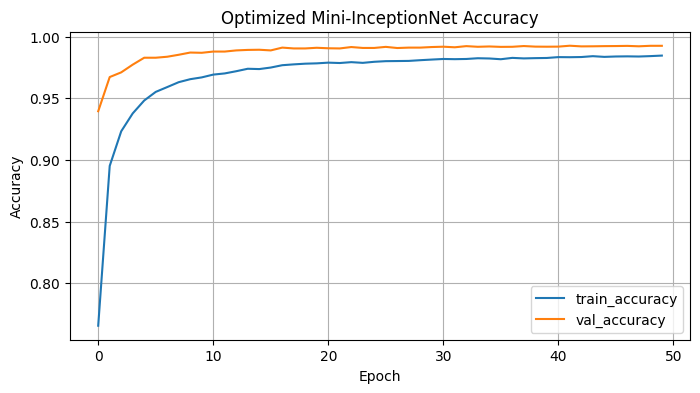

In [59]:
#khoi21
plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Optimized Mini-InceptionNet Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history.history["accuracy"], label="train_accuracy")
plt.plot(history.history["val_accuracy"], label="val_accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Optimized Mini-InceptionNet Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# int4/8

In [60]:
# ============================================================
# QUANTIZATION 01 - LOAD BEST MODEL + INSPECT LAYERS
# ============================================================

import os
import copy
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

best_quant_model_path = (
    "/kaggle/working/"
    "best_optimized_mini_inception.keras"
)

fp32_model = tf.keras.models.load_model(
    best_quant_model_path,
    compile=False
)

fp32_model.trainable = False

print("Loaded:", best_quant_model_path)
print("Model:", fp32_model.name)
print("Parameters:", f"{fp32_model.count_params():,}")


layer_rows = []

for index, layer in enumerate(
    fp32_model.layers
):
    weights = layer.get_weights()

    if len(weights) > 0:
        dtypes = sorted(
            set(
                str(w.dtype)
                for w in weights
            )
        )

        dtype_text = ", ".join(
            dtypes
        )
    else:
        dtype_text = "-"

    layer_rows.append({
        "Index":
            index,

        "Layer":
            layer.name,

        "Type":
            layer.__class__.__name__,

        "Parameters":
            layer.count_params(),

        "Weight dtype":
            dtype_text
    })


layer_df = pd.DataFrame(
    layer_rows
)

display(
    layer_df
)

Loaded: /kaggle/working/best_optimized_mini_inception.keras
Model: sep_res_inception_gelu_5class
Parameters: 6,473


,Index,Layer,Type,Parameters,Weight dtype
0,0,ecg_input,InputLayer,0,-
1,1,stem_conv_k7,Conv1D,56,float32
2,2,stem_bn,BatchNormalization,32,float32
3,3,stem_gelu,Activation,0,-
4,4,block1_b4_pool,MaxPooling1D,0,-
...,...,...,...,...,...
92,92,head_dense,Dense,960,float32
93,93,head_bn,BatchNormalization,96,float32
94,94,head_gelu,Activation,0,-
95,95,head_dropout,Dropout,0,-


In [61]:
# ============================================================
# QUANTIZATION 02 - SYMMETRIC FAKE QUANTIZATION
# ============================================================


def quant_limits(bits):
    if bits == 8:
        return -127, 127

    if bits == 4:
        return -7, 7

    raise ValueError(
        "Only INT4 and INT8 are supported."
    )


def fake_quant_tensor(
    x,
    bits
):
    x = tf.cast(
        x,
        tf.float32
    )

    qmin, qmax = quant_limits(
        bits
    )

    max_abs = tf.reduce_max(
        tf.abs(x)
    )

    scale = tf.maximum(
        max_abs / float(qmax),
        1e-8
    )

    q = tf.round(
        x / scale
    )

    q = tf.clip_by_value(
        q,
        float(qmin),
        float(qmax)
    )

    x_fake = (
        q * scale
    )

    return x_fake


def fake_quant_numpy(
    x,
    bits
):
    x = np.asarray(
        x,
        dtype=np.float32
    )

    qmin, qmax = quant_limits(
        bits
    )

    max_abs = float(
        np.max(
            np.abs(x)
        )
    )

    if max_abs < 1e-8:
        return x.copy()

    scale = (
        max_abs
        / float(qmax)
    )

    q = np.round(
        x / scale
    )

    q = np.clip(
        q,
        qmin,
        qmax
    )

    return (
        q * scale
    ).astype(
        np.float32
    )


def quantize_to_integer(
    x,
    bits
):
    x = np.asarray(
        x,
        dtype=np.float32
    )

    qmin, qmax = quant_limits(
        bits
    )

    max_abs = float(
        np.max(
            np.abs(x)
        )
    )

    if max_abs < 1e-8:
        scale = np.float32(
            1.0
        )

        q = np.zeros_like(
            x,
            dtype=np.int8
        )

        return q, scale

    scale = np.float32(
        max_abs
        / float(qmax)
    )

    q = np.round(
        x / scale
    )

    q = np.clip(
        q,
        qmin,
        qmax
    )

    q = q.astype(
        np.int8
    )

    return (
        q,
        scale
    )


print(
    "INT8 range:",
    quant_limits(8)
)

print(
    "INT4 range:",
    quant_limits(4)
)

INT8 range: (-127, 127)
INT4 range: (-7, 7)


In [62]:
# ============================================================
# QUANTIZATION 03 - ACTIVATION QUANTIZATION WRAPPER
# FIX FOR KERAS 3 MASK ARGUMENT
# ============================================================

class FakeQuantOutput(
    tf.keras.layers.Wrapper
):
    def __init__(
        self,
        layer,
        bits,
        quantize_output=True,
        **kwargs
    ):
        super().__init__(
            layer,
            **kwargs
        )

        self.bits = int(bits)

        self.quantize_output = bool(
            quantize_output
        )

    def call(
        self,
        inputs,
        training=None,
        mask=None,
        **kwargs
    ):
        # Không truyền mask xuống layer gốc vì model ECG
        # hiện tại không sử dụng Masking layer.

        try:
            output = self.layer(
                inputs,
                training=training,
                **kwargs
            )

        except TypeError:
            output = self.layer(
                inputs,
                **kwargs
            )

        if not self.quantize_output:
            return output

        return tf.nest.map_structure(
            lambda x: fake_quant_tensor(
                x,
                self.bits
            ),
            output
        )

    def get_config(self):
        config = super().get_config()

        config.update({
            "bits":
                self.bits,

            "quantize_output":
                self.quantize_output
        })

        return config

In [63]:
# ============================================================
# QUANTIZATION 04 - SELECT QUANTIZED ACTIVATION LAYERS
# ============================================================


def should_quantize_output(
    layer
):
    quantized_types = (
        tf.keras.layers.Activation,
        tf.keras.layers.MaxPooling1D,
        tf.keras.layers.Add,
        tf.keras.layers.Concatenate,
        tf.keras.layers.GlobalAveragePooling1D,
        tf.keras.layers.GlobalMaxPooling1D
    )

    if layer.name == "class_output":
        return False

    if isinstance(
        layer,
        quantized_types
    ):
        return True

    return False

In [64]:
# ============================================================
# QUANTIZATION 05 - BUILD UNIFORM QUANTIZED MODEL
# KERAS 3 COMPATIBLE
# ============================================================

WEIGHT_LAYER_TYPES = (
    tf.keras.layers.Conv1D,
    tf.keras.layers.SeparableConv1D,
    tf.keras.layers.Dense
)


def build_uniform_quant_model(
    base_model,
    bits
):
    if bits not in [4, 8]:
        raise ValueError(
            "bits must be 4 or 8"
        )

    def clone_function(layer):

        cloned_layer = (
            layer.__class__.from_config(
                layer.get_config()
            )
        )

        quantize_activation = (
            should_quantize_output(
                layer
            )
        )

        return FakeQuantOutput(
            cloned_layer,
            bits=bits,
            quantize_output=
                quantize_activation,
            name=(
                f"q{bits}_"
                f"{layer.name}"
            )
        )

    print(
        f"Cloning model for "
        f"W{bits}A{bits}..."
    )

    quant_model = (
        tf.keras.models.clone_model(
            base_model,
            clone_function=
                clone_function
        )
    )

    print(
        "Graph cloned successfully."
    )

    # --------------------------------------------------------
    # Map layer gốc -> layer bên trong wrapper
    # --------------------------------------------------------

    target_layers = {}

    for layer in quant_model.layers:

        if isinstance(
            layer,
            FakeQuantOutput
        ):
            target_layers[
                layer.layer.name
            ] = layer.layer

    # --------------------------------------------------------
    # Copy / quantize weights
    # --------------------------------------------------------

    for original_layer in (
        base_model.layers
    ):

        if (
            original_layer.name
            not in target_layers
        ):
            continue

        target_layer = (
            target_layers[
                original_layer.name
            ]
        )

        original_weights = (
            original_layer.get_weights()
        )

        if len(
            original_weights
        ) == 0:
            continue

        if isinstance(
            original_layer,
            WEIGHT_LAYER_TYPES
        ):

            new_weights = []

            for weight in (
                original_weights
            ):
                quantized_weight = (
                    fake_quant_numpy(
                        weight,
                        bits
                    )
                )

                new_weights.append(
                    quantized_weight
                )

            target_layer.set_weights(
                new_weights
            )

        else:
            target_layer.set_weights(
                original_weights
            )

    quant_model.trainable = False

    print(
        f"W{bits}A{bits} model ready."
    )

    return quant_model

In [65]:
# ============================================================
# QUANTIZATION 06 - CREATE W8A8 AND W4A4
# ============================================================

print(
    "Creating W8A8 model..."
)

int8_model = build_uniform_quant_model(
    fp32_model,
    bits=8
)


print(
    "\nCreating W4A4 model..."
)

int4_model = build_uniform_quant_model(
    fp32_model,
    bits=4
)


print(
    "\nDone."
)

print(
    "FP32 params:",
    f"{fp32_model.count_params():,}"
)

print(
    "W8A8 params:",
    f"{int8_model.count_params():,}"
)

print(
    "W4A4 params:",
    f"{int4_model.count_params():,}"
)

Creating W8A8 model...
Cloning model for W8A8...
Graph cloned successfully.
W8A8 model ready.

Creating W4A4 model...
Cloning model for W4A4...
Graph cloned successfully.
W4A4 model ready.

Done.
FP32 params: 6,473
W8A8 params: 6,473
W4A4 params: 6,473


In [66]:
# ============================================================
# QUANTIZATION 07 - TEST LABELS
# ============================================================


y_test_quant = np.asarray(
    y_test
)

if y_test_quant.ndim > 1:
    y_test_quant = np.argmax(
        y_test_quant,
        axis=1
    )

y_test_quant = (
    y_test_quant
    .astype(
        np.int32
    )
    .ravel()
)

print(
    "Test samples:",
    len(
        y_test_quant
    )
)

print(
    "Classes:",
    LABELS
)

Test samples: 15009
Classes: ['N', 'L', 'R', 'V', 'A']


In [67]:
# ============================================================
# QUANTIZATION 08 - EVALUATION FUNCTION
# ============================================================


def evaluate_quant_model(
    model,
    X,
    y_true,
    bits=None,
    batch_size=512
):
    if bits is None:

        probabilities = model.predict(
            X,
            batch_size=batch_size,
            verbose=0
        )

    else:

        dataset = (
            tf.data.Dataset
            .from_tensor_slices(
                X.astype(
                    np.float32
                )
            )
            .batch(
                batch_size
            )
        )

        dataset = dataset.map(
            lambda x:
                fake_quant_tensor(
                    x,
                    bits
                ),
            num_parallel_calls=
                tf.data.AUTOTUNE
        )

        probabilities = (
            model.predict(
                dataset,
                verbose=0
            )
        )


    prediction = np.argmax(
        probabilities,
        axis=1
    )


    accuracy = accuracy_score(
        y_true,
        prediction
    )


    macro_f1 = f1_score(
        y_true,
        prediction,
        labels=list(
            range(
                len(LABELS)
            )
        ),
        average="macro",
        zero_division=0
    )


    per_class_f1 = f1_score(
        y_true,
        prediction,
        labels=list(
            range(
                len(LABELS)
            )
        ),
        average=None,
        zero_division=0
    )


    return {
        "accuracy":
            float(
                accuracy
            ),

        "macro_f1":
            float(
                macro_f1
            ),

        "per_class_f1":
            per_class_f1,

        "prediction":
            prediction
    }

# fp32 test

In [68]:
# ============================================================
# QUANTIZATION 09 - FP32 TEST
# ============================================================


fp32_result = (
    evaluate_quant_model(
        fp32_model,
        X_test_keras,
        y_test_quant,
        bits=None
    )
)


print(
    "FP32 Accuracy:",
    f"{fp32_result['accuracy']*100:.2f}%"
)

print(
    "FP32 Macro F1:",
    f"{fp32_result['macro_f1']:.4f}"
)

for label, score in zip(
    LABELS,
    fp32_result[
        "per_class_f1"
    ]
):
    print(
        f"{label} F1: "
        f"{score:.4f}"
    )

FP32 Accuracy: 99.21%
FP32 Macro F1: 0.9732
N F1: 0.9954
L F1: 0.9942
R F1: 0.9927
V F1: 0.9813
A F1: 0.9025


# int8 test

In [69]:
# ============================================================
# QUANTIZATION 10 - W8A8 TEST
# ============================================================


int8_result = (
    evaluate_quant_model(
        int8_model,
        X_test_keras,
        y_test_quant,
        bits=8
    )
)


print(
    "W8A8 Accuracy:",
    f"{int8_result['accuracy']*100:.2f}%"
)

print(
    "W8A8 Macro F1:",
    f"{int8_result['macro_f1']:.4f}"
)

for label, score in zip(
    LABELS,
    int8_result[
        "per_class_f1"
    ]
):
    print(
        f"{label} F1: "
        f"{score:.4f}"
    )

W8A8 Accuracy: 99.21%
W8A8 Macro F1: 0.9744
N F1: 0.9956
L F1: 0.9937
R F1: 0.9923
V F1: 0.9779
A F1: 0.9124


# int4 test

In [70]:
# ============================================================
# QUANTIZATION 11 - W4A4 TEST
# ============================================================


int4_result = (
    evaluate_quant_model(
        int4_model,
        X_test_keras,
        y_test_quant,
        bits=4
    )
)


print(
    "W4A4 Accuracy:",
    f"{int4_result['accuracy']*100:.2f}%"
)

print(
    "W4A4 Macro F1:",
    f"{int4_result['macro_f1']:.4f}"
)

for label, score in zip(
    LABELS,
    int4_result[
        "per_class_f1"
    ]
):
    print(
        f"{label} F1: "
        f"{score:.4f}"
    )

W4A4 Accuracy: 27.44%
W4A4 Macro F1: 0.1246
N F1: 0.4513
L F1: 0.0161
R F1: 0.0612
V F1: 0.0359
A F1: 0.0583


In [71]:
# ============================================================
# QUANTIZATION 12 - COMPARISON TABLE
# ============================================================


comparison_rows = []


for (
    model_name,
    bits,
    result
) in [
    (
        "FP32",
        32,
        fp32_result
    ),
    (
        "W8A8",
        8,
        int8_result
    ),
    (
        "W4A4",
        4,
        int4_result
    )
]:

    row = {
        "Model":
            model_name,

        "Bits":
            bits,

        "Accuracy (%)":
            result[
                "accuracy"
            ] * 100,

        "Macro F1":
            result[
                "macro_f1"
            ]
    }

    for label, score in zip(
        LABELS,
        result[
            "per_class_f1"
        ]
    ):
        row[
            f"F1_{label}"
        ] = score

    comparison_rows.append(
        row
    )


comparison_df = pd.DataFrame(
    comparison_rows
)

display(
    comparison_df.round(
        4
    )
)


comparison_path = (
    "/kaggle/working/"
    "fp32_int8_int4_comparison.csv"
)

comparison_df.to_csv(
    comparison_path,
    index=False
)

print(
    "Saved:",
    comparison_path
)

,Model,Bits,Accuracy (%),Macro F1,F1_N,F1_L,F1_R,F1_V,F1_A
0,FP32,32,99.2071,0.9732,0.9954,0.9942,0.9927,0.9813,0.9025
1,W8A8,8,99.2138,0.9744,0.9956,0.9937,0.9923,0.9779,0.9124
2,W4A4,4,27.4435,0.1246,0.4513,0.0161,0.0612,0.0359,0.0583


Saved: /kaggle/working/fp32_int8_int4_comparison.csv


In [72]:
# ============================================================
# QUANTIZATION 13 - THEORETICAL MODEL SIZE
# ============================================================


parameter_count = (
    fp32_model.count_params()
)


def model_size_kib(
    parameter_count,
    bits
):
    return (
        parameter_count
        * bits
        / 8
        / 1024
    )


size_df = pd.DataFrame({
    "Precision": [
        "FP32",
        "INT8",
        "INT4"
    ],

    "Bits": [
        32,
        8,
        4
    ],

    "Theoretical Size (KiB)": [
        model_size_kib(
            parameter_count,
            32
        ),

        model_size_kib(
            parameter_count,
            8
        ),

        model_size_kib(
            parameter_count,
            4
        )
    ]
})


display(
    size_df.round(
        3
    )
)

,Precision,Bits,Theoretical Size (KiB)
0,FP32,32,25.285
1,INT8,8,6.321
2,INT4,4,3.161


In [73]:
# ============================================================
# QUANTIZATION 14 - EXPORT INTEGER WEIGHTS
# ============================================================


def export_integer_weights(
    model,
    bits,
    output_path
):
    export_data = {}


    for layer in model.layers:

        if not isinstance(
            layer,
            (
                tf.keras.layers.Conv1D,
                tf.keras.layers.SeparableConv1D,
                tf.keras.layers.Dense
            )
        ):
            continue


        weights = (
            layer.get_weights()
        )

        if len(weights) == 0:
            continue


        if isinstance(
            layer,
            tf.keras.layers.SeparableConv1D
        ):
            weight_names = [
                "depthwise_kernel",
                "pointwise_kernel"
            ]

            if layer.use_bias:
                weight_names.append(
                    "bias"
                )

        else:
            weight_names = [
                "kernel"
            ]

            if getattr(
                layer,
                "use_bias",
                False
            ):
                weight_names.append(
                    "bias"
                )


        for weight_name, weight in zip(
            weight_names,
            weights
        ):

            q_weight, scale = (
                quantize_to_integer(
                    weight,
                    bits
                )
            )

            key = (
                f"{layer.name}_"
                f"{weight_name}"
            )

            export_data[
                key
            ] = q_weight

            export_data[
                f"{key}_scale"
            ] = np.asarray(
                scale,
                dtype=np.float32
            )


    np.savez_compressed(
        output_path,
        **export_data
    )

    print(
        "Saved:",
        output_path
    )


export_integer_weights(
    fp32_model,
    bits=8,
    output_path=(
        "/kaggle/working/"
        "inception_weights_int8.npz"
    )
)


export_integer_weights(
    fp32_model,
    bits=4,
    output_path=(
        "/kaggle/working/"
        "inception_weights_int4.npz"
    )
)

Saved: /kaggle/working/inception_weights_int8.npz
Saved: /kaggle/working/inception_weights_int4.npz


# NAS

In [74]:
# ============================================================
# NAS 01 - SEARCH SPACE
# ============================================================

KERNEL_PATTERNS = [
    (3, 5, 7),
    (3, 5, 9),
    (3, 7, 9)
]

CHANNEL_CHOICES = {
    "block1": [8, 12, 16],
    "block2": [12, 16, 20],
    "block3": [16, 20, 24],
    "block4": [20, 24, 28, 32]
}

PRECISION_CHOICES = [
    4,
    8
]

print("Kernel candidates:")
for item in KERNEL_PATTERNS:
    print(item)

print("\nChannel candidates:")
for block, choices in CHANNEL_CHOICES.items():
    print(block, choices)

print(
    "\nPrecision candidates:",
    PRECISION_CHOICES
)

Kernel candidates:
(3, 5, 7)
(3, 5, 9)
(3, 7, 9)

Channel candidates:
block1 [8, 12, 16]
block2 [12, 16, 20]
block3 [16, 20, 24]
block4 [20, 24, 28, 32]

Precision candidates: [4, 8]


In [75]:
# ============================================================
# NAS 02 - CONFIGURABLE INCEPTION BLOCK
# ============================================================

def nas_sep_conv_branch(
    x,
    filters,
    kernel_size,
    dilation_rate=1,
    name="branch"
):
    y = layers.SeparableConv1D(
        filters=filters,
        kernel_size=kernel_size,
        padding="same",
        dilation_rate=dilation_rate,
        use_bias=False,
        depthwise_regularizer=
            regularizers.l2(L2_LAMBDA),
        pointwise_regularizer=
            regularizers.l2(L2_LAMBDA),
        name=f"{name}_sepconv"
    )(x)

    y = layers.BatchNormalization(
        name=f"{name}_bn"
    )(y)

    y = layers.Activation(
        "gelu",
        name=f"{name}_act"
    )(y)

    return y


def nas_inception_block(
    x,
    filters,
    kernels,
    dropout_rate,
    block_name
):
    shortcut = x

    branch_filters = max(
        filters // 2,
        4
    )

    k1, k2, k3 = kernels

    b1 = nas_sep_conv_branch(
        x,
        branch_filters,
        kernel_size=k1,
        dilation_rate=1,
        name=f"{block_name}_b1"
    )

    b2 = nas_sep_conv_branch(
        x,
        branch_filters,
        kernel_size=k2,
        dilation_rate=1,
        name=f"{block_name}_b2"
    )

    b3 = nas_sep_conv_branch(
        x,
        branch_filters,
        kernel_size=k3,
        dilation_rate=2,
        name=f"{block_name}_b3"
    )

    b4 = layers.MaxPooling1D(
        pool_size=3,
        strides=1,
        padding="same",
        name=f"{block_name}_pool"
    )(x)

    b4 = layers.Conv1D(
        branch_filters,
        kernel_size=1,
        padding="same",
        use_bias=False,
        kernel_regularizer=
            regularizers.l2(L2_LAMBDA),
        name=f"{block_name}_pool_proj"
    )(b4)

    b4 = layers.BatchNormalization(
        name=f"{block_name}_pool_bn"
    )(b4)

    b4 = layers.Activation(
        "gelu",
        name=f"{block_name}_pool_act"
    )(b4)

    y = layers.Concatenate(
        name=f"{block_name}_concat"
    )([
        b1,
        b2,
        b3,
        b4
    ])

    y = layers.Conv1D(
        filters,
        kernel_size=1,
        padding="same",
        use_bias=False,
        kernel_regularizer=
            regularizers.l2(L2_LAMBDA),
        name=f"{block_name}_out_proj"
    )(y)

    y = layers.BatchNormalization(
        name=f"{block_name}_out_bn"
    )(y)

    if int(
        shortcut.shape[-1]
    ) != filters:

        shortcut = layers.Conv1D(
            filters,
            kernel_size=1,
            padding="same",
            use_bias=False,
            kernel_regularizer=
                regularizers.l2(L2_LAMBDA),
            name=f"{block_name}_shortcut"
        )(shortcut)

        shortcut = layers.BatchNormalization(
            name=f"{block_name}_shortcut_bn"
        )(shortcut)

    y = layers.Add(
        name=f"{block_name}_add"
    )([
        shortcut,
        y
    ])

    y = layers.Activation(
        "gelu",
        name=f"{block_name}_act"
    )(y)

    y = layers.SpatialDropout1D(
        dropout_rate,
        name=f"{block_name}_drop"
    )(y)

    return y

In [76]:
# ============================================================
# NAS 03 - BUILD MODEL FROM CONFIG
# ============================================================

def build_nas_model(
    config
):
    inp = layers.Input(
        shape=input_shape_5,
        name="ecg_input"
    )

    x = layers.Conv1D(
        8,
        kernel_size=7,
        padding="same",
        use_bias=False,
        kernel_regularizer=
            regularizers.l2(L2_LAMBDA),
        name="stem_conv"
    )(inp)

    x = layers.BatchNormalization(
        name="stem_bn"
    )(x)

    x = layers.Activation(
        "gelu",
        name="stem_act"
    )(x)

    x = nas_inception_block(
        x,
        filters=config[
            "block1_channels"
        ],
        kernels=config[
            "block1_kernels"
        ],
        dropout_rate=
            DROPOUT_1,
        block_name="block1"
    )

    x = layers.MaxPooling1D(
        pool_size=2,
        name="pool1"
    )(x)

    x = nas_inception_block(
        x,
        filters=config[
            "block2_channels"
        ],
        kernels=config[
            "block2_kernels"
        ],
        dropout_rate=
            DROPOUT_1,
        block_name="block2"
    )

    x = layers.MaxPooling1D(
        pool_size=2,
        name="pool2"
    )(x)

    x = nas_inception_block(
        x,
        filters=config[
            "block3_channels"
        ],
        kernels=config[
            "block3_kernels"
        ],
        dropout_rate=
            DROPOUT_2,
        block_name="block3"
    )

    x = layers.MaxPooling1D(
        pool_size=2,
        name="pool3"
    )(x)

    x = nas_inception_block(
        x,
        filters=config[
            "block4_channels"
        ],
        kernels=config[
            "block4_kernels"
        ],
        dropout_rate=
            DROPOUT_2,
        block_name="block4"
    )

    gap = layers.GlobalAveragePooling1D(
        name="gap"
    )(x)

    gmp = layers.GlobalMaxPooling1D(
        name="gmp"
    )(x)

    x = layers.Concatenate(
        name="head_concat"
    )([
        gap,
        gmp
    ])

    x = layers.Dense(
        24,
        use_bias=False,
        kernel_regularizer=
            regularizers.l2(L2_LAMBDA),
        name="head_dense"
    )(x)

    x = layers.BatchNormalization(
        name="head_bn"
    )(x)

    x = layers.Activation(
        "gelu",
        name="head_act"
    )(x)

    x = layers.Dropout(
        DROPOUT_HEAD,
        name="head_dropout"
    )(x)

    out = layers.Dense(
        NUM_CLASSES_5,
        activation="softmax",
        name="class_output"
    )(x)

    model = Model(
        inp,
        out,
        name="nas_inception"
    )

    model.compile(
        optimizer=
            tf.keras.optimizers.Adam(
                learning_rate=1e-3
            ),
        loss=
            tf.keras.losses
            .CategoricalCrossentropy(
                label_smoothing=0.03
            ),
        metrics=[
            "accuracy"
        ]
    )

    return model

In [77]:
# ============================================================
# NAS 04 - SAMPLE ARCHITECTURE
# ============================================================

import random


def sample_architecture():

    return {
        "block1_kernels":
            random.choice(
                KERNEL_PATTERNS
            ),

        "block1_channels":
            random.choice(
                CHANNEL_CHOICES[
                    "block1"
                ]
            ),

        "block2_kernels":
            random.choice(
                KERNEL_PATTERNS
            ),

        "block2_channels":
            random.choice(
                CHANNEL_CHOICES[
                    "block2"
                ]
            ),

        "block3_kernels":
            random.choice(
                KERNEL_PATTERNS
            ),

        "block3_channels":
            random.choice(
                CHANNEL_CHOICES[
                    "block3"
                ]
            ),

        "block4_kernels":
            random.choice(
                KERNEL_PATTERNS
            ),

        "block4_channels":
            random.choice(
                CHANNEL_CHOICES[
                    "block4"
                ]
            )
    }


for _ in range(3):
    print(
        sample_architecture()
    )

{'block1_kernels': (3, 7, 9), 'block1_channels': 12, 'block2_kernels': (3, 7, 9), 'block2_channels': 16, 'block3_kernels': (3, 5, 7), 'block3_channels': 16, 'block4_kernels': (3, 5, 9), 'block4_channels': 24}
{'block1_kernels': (3, 7, 9), 'block1_channels': 16, 'block2_kernels': (3, 7, 9), 'block2_channels': 16, 'block3_kernels': (3, 5, 9), 'block3_channels': 20, 'block4_kernels': (3, 5, 9), 'block4_channels': 20}
{'block1_kernels': (3, 5, 7), 'block1_channels': 16, 'block2_kernels': (3, 5, 7), 'block2_channels': 16, 'block3_kernels': (3, 5, 9), 'block3_channels': 24, 'block4_kernels': (3, 5, 9), 'block4_channels': 20}


In [78]:
# ============================================================
# NAS 05 - MAC ESTIMATOR
# ============================================================

def estimate_macs(
    model
):
    total_macs = 0

    for layer in (
        model.layers
    ):

        if isinstance(
            layer,
            tf.keras.layers.Conv1D
        ):
            cin = int(
                layer.input.shape[-1]
            )

            cout = int(
                layer.filters
            )

            length = int(
                layer.output.shape[1]
            )

            kernel = int(
                layer.kernel_size[0]
            )

            total_macs += (
                length
                * cin
                * cout
                * kernel
            )

        elif isinstance(
            layer,
            tf.keras.layers.SeparableConv1D
        ):
            cin = int(
                layer.input.shape[-1]
            )

            cout = int(
                layer.filters
            )

            length = int(
                layer.output.shape[1]
            )

            kernel = int(
                layer.kernel_size[0]
            )

            depth_multiplier = int(
                layer.depth_multiplier
            )

            depthwise = (
                length
                * cin
                * kernel
                * depth_multiplier
            )

            pointwise = (
                length
                * cin
                * depth_multiplier
                * cout
            )

            total_macs += (
                depthwise
                + pointwise
            )

        elif isinstance(
            layer,
            tf.keras.layers.Dense
        ):
            total_macs += (
                int(
                    layer.input.shape[-1]
                )
                * int(
                    layer.units
                )
            )

    return int(
        total_macs
    )

In [79]:
# ============================================================
# NAS 06 - EVALUATE ONE ARCHITECTURE
# ============================================================

def evaluate_architecture(
    config,
    search_epochs=5
):
    model = build_nas_model(
        config
    )

    callbacks_search = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=2,
            restore_best_weights=True,
            verbose=0
        )
    ]

    model.fit(
        X_train_keras,
        y_train_cat,

        validation_data=(
            X_val_keras,
            y_val_cat
        ),

        epochs=search_epochs,
        batch_size=BATCH_SIZE,

        callbacks=
            callbacks_search,

        shuffle=True,
        verbose=0
    )

    y_prob = model.predict(
        X_val_keras,
        batch_size=512,
        verbose=0
    )

    y_pred = np.argmax(
        y_prob,
        axis=1
    )

    y_true = np.argmax(
        y_val_cat,
        axis=1
    )

    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    params = (
        model.count_params()
    )

    macs = estimate_macs(
        model
    )

    return {
        "macro_f1":
            float(
                macro_f1
            ),

        "params":
            int(
                params
            ),

        "macs":
            int(
                macs
            )
    }

In [80]:
# ============================================================
# NAS 07 - RANDOM ARCHITECTURE SEARCH
# ============================================================

NUM_ARCH_CANDIDATES = 20
SEARCH_EPOCHS = 5

architecture_results = []


for candidate_id in range(
    NUM_ARCH_CANDIDATES
):

    config = sample_architecture()

    print(
        f"\nCandidate "
        f"{candidate_id + 1}/"
        f"{NUM_ARCH_CANDIDATES}"
    )

    print(
        config
    )

    result = evaluate_architecture(
        config,
        search_epochs=
            SEARCH_EPOCHS
    )

    print(
        "Macro F1:",
        round(
            result[
                "macro_f1"
            ],
            4
        )
    )

    print(
        "Params:",
        f"{result['params']:,}"
    )

    print(
        "MACs:",
        f"{result['macs']:,}"
    )

    architecture_results.append({
        "id":
            candidate_id,

        "config":
            config,

        **result
    })

    tf.keras.backend.clear_session()


Candidate 1/20
{'block1_kernels': (3, 5, 9), 'block1_channels': 12, 'block2_kernels': (3, 5, 7), 'block2_channels': 16, 'block3_kernels': (3, 5, 9), 'block3_channels': 20, 'block4_kernels': (3, 5, 9), 'block4_channels': 20}
Macro F1: 0.9549
Params: 8,229
MACs: 689,880

Candidate 2/20
{'block1_kernels': (3, 7, 9), 'block1_channels': 8, 'block2_kernels': (3, 5, 9), 'block2_channels': 20, 'block3_kernels': (3, 5, 9), 'block3_channels': 16, 'block4_kernels': (3, 5, 7), 'block4_channels': 32}
Macro F1: 0.9636
Params: 10,489
MACs: 674,616

Candidate 3/20
{'block1_kernels': (3, 5, 9), 'block1_channels': 16, 'block2_kernels': (3, 5, 9), 'block2_channels': 12, 'block3_kernels': (3, 5, 7), 'block3_channels': 24, 'block4_kernels': (3, 7, 9), 'block4_channels': 20}
Macro F1: 0.955
Params: 9,481
MACs: 814,520

Candidate 4/20
{'block1_kernels': (3, 5, 7), 'block1_channels': 16, 'block2_kernels': (3, 7, 9), 'block2_channels': 20, 'block3_kernels': (3, 7, 9), 'block3_channels': 20, 'block4_kernels': 

In [81]:
# ============================================================
# NAS 08 - HARDWARE-AWARE RANKING
# ============================================================

max_params = max(
    item["params"]
    for item
    in architecture_results
)

max_macs = max(
    item["macs"]
    for item
    in architecture_results
)


for item in (
    architecture_results
):

    param_cost = (
        item["params"]
        / max_params
    )

    mac_cost = (
        item["macs"]
        / max_macs
    )

    item["score"] = (
        item["macro_f1"]
        - 0.02
        * param_cost
        - 0.03
        * mac_cost
    )


architecture_results = sorted(
    architecture_results,
    key=lambda x:
        x["score"],
    reverse=True
)


best_arch = (
    architecture_results[0]
)


print(
    "BEST ARCHITECTURE"
)

print(
    "Score:",
    best_arch["score"]
)

print(
    "Macro F1:",
    best_arch["macro_f1"]
)

print(
    "Parameters:",
    best_arch["params"]
)

print(
    "MACs:",
    best_arch["macs"]
)

print(
    "\nConfiguration:"
)

print(
    best_arch["config"]
)

BEST ARCHITECTURE
Score: 0.930111185643802
Macro F1: 0.9633908682080834
Parameters: 8929
MACs: 593752

Configuration:
{'block1_kernels': (3, 7, 9), 'block1_channels': 8, 'block2_kernels': (3, 5, 9), 'block2_channels': 16, 'block3_kernels': (3, 5, 7), 'block3_channels': 20, 'block4_kernels': (3, 7, 9), 'block4_channels': 24}


# best

In [82]:
BEST_CONFIG = {
    "block1_kernels": (3, 5, 7),
    "block1_channels": 8,

    "block2_kernels": (3, 5, 9),
    "block2_channels": 12,

    "block3_kernels": (3, 5, 9),
    "block3_channels": 24,

    "block4_kernels": (3, 7, 9),
    "block4_channels": 28
}

In [83]:
best_arch_model = build_nas_model(
    BEST_CONFIG
)

best_arch_model.summary()

print(
    "Parameters:",
    f"{best_arch_model.count_params():,}"
)

print(
    "MACs:",
    f"{estimate_macs(best_arch_model):,}"
)

Model: "nas_inception"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ ecg_input           │ (None, 320, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv1D)  │ (None, 320, 8)    │         56 │ ecg_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 320, 8)    │         32 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_act            │ (None, 320, 8)    │          0 │ stem_bn[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 320, 8)    │          0 │ stem_act[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_b1_sepconv   │ (None, 320, 4)    │         56 │ stem_act[0][0]    │
│ (SeparableConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_b2_sepconv   │ (None, 320, 4)    │         72 │ stem_act[0][0]    │
│ (SeparableConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_b3_sepconv   │ (None, 320, 4)    │         88 │ stem_act[0][0]    │
│ (SeparableConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool_proj    │ (None, 320, 4)    │         32 │ block1_pool[0][0] │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_b1_bn        │ (None, 320, 4)    │         16 │ block1_b1_sepcon… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_b2_bn        │ (None, 320, 4)    │         16 │ block1_b2_sepcon… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_b3_bn        │ (None, 320, 4)    │         16 │ block1_b3_sepcon… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool_bn      │ (None, 320, 4)    │         16 │ block1_pool_proj… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_b1_act       │ (None, 320, 4)    │          0 │ block1_b1_bn[0][… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_b2_act       │ (None, 320, 4)    │          0 │ block1_b2_bn[0][… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_b3_act       │ (None, 320, 4)    │          0 │ block1_b3_bn[0][… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool_act     │ (None, 320, 4)    │          0 │ block1_pool_bn[0… │
│ (Activation)        │                   │            │                 

 Total params: 10,121 (39.54 KB)

 Trainable params: 9,497 (37.10 KB)

 Non-trainable params: 624 (2.44 KB)

Parameters: 10,121
MACs: 592,824


In [84]:
BEST_ARCH_PATH = (
    "/kaggle/working/"
    "best_nas_architecture_fp32.keras"
)

callbacks_best = [

    tf.keras.callbacks.ModelCheckpoint(
        BEST_ARCH_PATH,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]


history_best_arch = best_arch_model.fit(

    X_train_keras,
    y_train_cat,

    validation_data=(
        X_val_keras,
        y_val_cat
    ),

    epochs=50,

    batch_size=BATCH_SIZE,

    callbacks=callbacks_best,

    shuffle=True,

    verbose=1
)

Epoch 1/50
644/644 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.7016 - loss: 0.9585
Epoch 1: val_loss improved from None to 0.31316, saving model to /kaggle/working/best_nas_architecture_fp32.keras

Epoch 1: finished saving model to /kaggle/working/best_nas_architecture_fp32.keras
644/644 ━━━━━━━━━━━━━━━━━━━━ 81s 69ms/step - accuracy: 0.8052 - loss: 0.7195 - val_accuracy: 0.9578 - val_loss: 0.3132 - learning_rate: 0.0010
Epoch 2/50
642/644 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9073 - loss: 0.4676
Epoch 2: val_loss improved from 0.31316 to 0.26847, saving model to /kaggle/working/best_nas_architecture_fp32.keras

Epoch 2: finished saving model to /kaggle/working/best_nas_architecture_fp32.keras
644/644 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.9174 - loss: 0.4394 - val_accuracy: 0.9714 - val_loss: 0.2685 - learning_rate: 0.0010
Epoch 3/50
643/644 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9351 - loss: 0.3853
Epoch 3: val_loss improved from 0.26847 to 0.24313, sa

In [85]:
best_arch_model = (
    tf.keras.models.load_model(
        BEST_ARCH_PATH,
        compile=False
    )
)

In [86]:
y_val_prob = best_arch_model.predict(
    X_val_keras,
    batch_size=512,
    verbose=0
)

y_val_pred = np.argmax(
    y_val_prob,
    axis=1
)

y_val_true = np.argmax(
    y_val_cat,
    axis=1
)

best_arch_val_f1 = f1_score(
    y_val_true,
    y_val_pred,
    average="macro",
    zero_division=0
)

best_arch_val_acc = accuracy_score(
    y_val_true,
    y_val_pred
)

print(
    "Best NAS FP32 Accuracy:",
    best_arch_val_acc
)

print(
    "Best NAS FP32 Macro F1:",
    best_arch_val_f1
)

Best NAS FP32 Accuracy: 0.9939373750832778
Best NAS FP32 Macro F1: 0.9824257532301777


In [87]:
best_arch_model.save(
    "/kaggle/working/best_nas_fp32.keras"
)